# Market Making: Avellaneda-Stoikov Model

Simulate optimal market making under inventory risk (Avellaneda–Stoikov, 2008): reservation price, optimal half-spread, Poisson fills, and $\gamma$ sensitivity.

**Theory references:** [Avellaneda-Stoikov](../theory/03_market_making/avellaneda_stoikov.md) | [Inventory Risk](../theory/03_market_making/inventory_risk.md) | [Bid-Ask Spread](../theory/03_market_making/bid_ask_spread.md)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.labelsize': 11,
    'axes.titlesize': 12, 'axes.titleweight': 'normal',
    'legend.fontsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
COLORS = ['#534AB7', '#0F6E56', '#D85A30', '#185FA5', '#993556', '#3B6D11', '#BA7517']

import os


def save_fig(fig, topic: str, name: str) -> None:
    folder = os.path.join('..', 'plots', topic)
    os.makedirs(folder, exist_ok=True)
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(folder, f'{name}.{ext}'))


## Section 1 — Avellaneda-Stoikov Model

The mid-price follows $dS=\sigma\,dW$, order arrivals decay with distance as $\lambda\propto e^{-\kappa\delta}$, and CARA utility implies the reservation price $r_t=S_t-q_t\gamma\sigma^2(T-t)$ and the optimal half-spread $\delta^*$ used in the code. Full derivation and context are in [avellaneda_stoikov.md](../theory/03_market_making/avellaneda_stoikov.md), [inventory_risk.md](../theory/03_market_making/inventory_risk.md), and [bid_ask_spread.md](../theory/03_market_making/bid_ask_spread.md).


In [12]:
def simulate_mid_price(S0: float, sigma: float, T: float, n_steps: int,
                       rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """Simulate mid-price as arithmetic Brownian motion. Returns (time_grid, prices)."""
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    dW = rng.normal(0.0, np.sqrt(dt), n_steps)
    S = np.empty(n_steps + 1)
    S[0] = S0
    S[1:] = S0 + np.cumsum(sigma * dW)
    return t, S


In [13]:
def avellaneda_stoikov_sim(S0: float, sigma: float, T: float, n_steps: int,
                           gamma: float, kappa: float, A: float,
                           rng: np.random.Generator,
                           adverse_premium_scale: float = 1.0,
                           mid_path=None) -> dict:
    """One trading session: AS quotes, Poisson-style fills, inventory and PnL.

    adverse_premium_scale multiplies the closed-form term (1/gamma)*ln(1+gamma/kappa)
    only; gamma and kappa in the fill intensity lambda = A*exp(-kappa*delta) are unchanged.
    Pass mid_path=(t, S) to reuse the same mid-price path across scenarios.
    """
    dt = T / n_steps
    if mid_path is None:
        t, S = simulate_mid_price(S0, sigma, T, n_steps, rng)
    else:
        t, S = mid_path
        if len(t) != n_steps + 1 or len(S) != n_steps + 1:
            raise ValueError('mid_path must be (t, S) with length n_steps+1')
    q = np.zeros(n_steps + 1)
    cash = np.zeros(n_steps + 1)
    bid = np.zeros(n_steps + 1)
    ask = np.zeros(n_steps + 1)
    res = np.zeros(n_steps + 1)
    spread_rev = np.zeros(n_steps + 1)
    n_fills = 0
    for i in range(n_steps):
        tau = max(T - t[i], 1e-10)
        r = S[i] - q[i] * gamma * sigma**2 * tau
        adverse_half = (1.0 / gamma) * np.log(1.0 + gamma / kappa)
        half_spread = gamma * sigma**2 * tau / 2.0 + adverse_premium_scale * adverse_half
        bid_price = r - half_spread
        ask_price = r + half_spread
        res[i] = r
        bid[i] = bid_price
        ask[i] = ask_price
        delta_a = max(ask_price - S[i], 0.0)
        delta_b = max(S[i] - bid_price, 0.0)
        p_ask = min(A * np.exp(-kappa * delta_a) * dt, 1.0)
        p_bid = min(A * np.exp(-kappa * delta_b) * dt, 1.0)
        ask_fill = rng.random() < p_ask
        bid_fill = rng.random() < p_bid
        new_q, new_cash, new_sr = q[i], cash[i], spread_rev[i]
        if ask_fill:
            new_cash += ask_price
            new_q -= 1.0
            new_sr += delta_a
            n_fills += 1
        if bid_fill:
            new_cash -= bid_price
            new_q += 1.0
            new_sr += delta_b
            n_fills += 1
        q[i + 1] = new_q
        cash[i + 1] = new_cash
        spread_rev[i + 1] = new_sr
    res[-1] = S[-1] - q[-1] * gamma * sigma**2 * 1e-10
    bid[-1] = res[-1]
    ask[-1] = res[-1]
    pnl = cash + q * S
    return {
        'time': t, 'mid': S, 'bid': bid, 'ask': ask, 'reservation': res,
        'inventory': q, 'cash': cash, 'pnl': pnl,
        'spread_revenue': spread_rev, 'n_fills': n_fills,
    }


## Section 2 — Simulation

The following code generates the mid-price path, Poisson order hits, reservation quotes, inventory, spread revenue, and mark-to-market PnL for one Avellaneda–Stoikov session with the parameters set in the next cells.


In [14]:
rng = np.random.default_rng(42)
result = avellaneda_stoikov_sim(
    S0=100.0, sigma=2.0, T=1.0, n_steps=3600,
    gamma=0.1, kappa=1.5, A=140.0, rng=rng
)
print(f'Total fills:      {result["n_fills"]}')
print(f'Final inventory:  {result["inventory"][-1]:.0f}')
print(f'Final PnL:        {result["pnl"][-1]:.2f}')
print(f'Spread revenue:   {result["spread_revenue"][-1]:.2f}')


Total fills:      103
Final inventory:  5
Final PnL:        72.58
Spread revenue:   67.99


## Section 3 — Analysis

The figures show how bid and ask track the mid while shifting around $r_t$, how inventory mean-reverts, how spread revenue compares to inventory PnL, and how terminal PnL varies with $\gamma$.


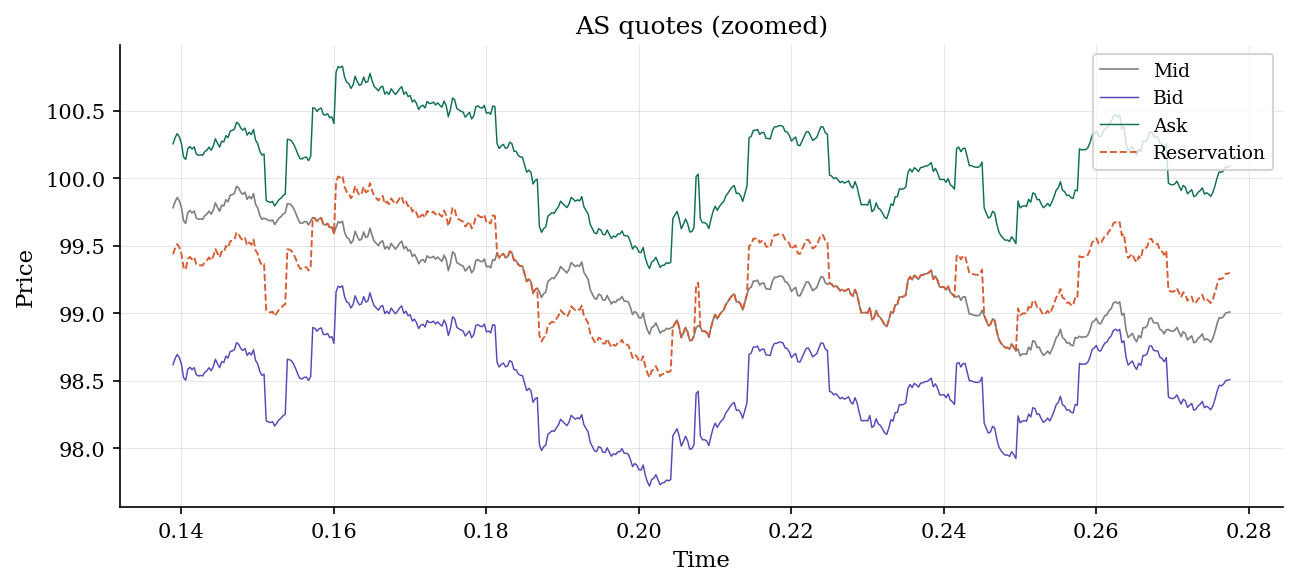

In [15]:
lo, hi = 500, 1000
t_s = result['time'][lo:hi]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_s, result['mid'][lo:hi], color='gray', lw=0.8, label='Mid')
ax.plot(t_s, result['bid'][lo:hi], color=COLORS[0], lw=0.7, label='Bid')
ax.plot(t_s, result['ask'][lo:hi], color=COLORS[1], lw=0.7, label='Ask')
ax.plot(t_s, result['reservation'][lo:hi], color=COLORS[2], ls='--', lw=0.9, label='Reservation')
ax.set_xlabel('Time')
ax.set_ylabel('Price')
ax.set_title('AS quotes (zoomed)')
ax.legend(loc='upper right', fontsize=9)
save_fig(fig, '03_market_making', 'as_quotes')
plt.show()


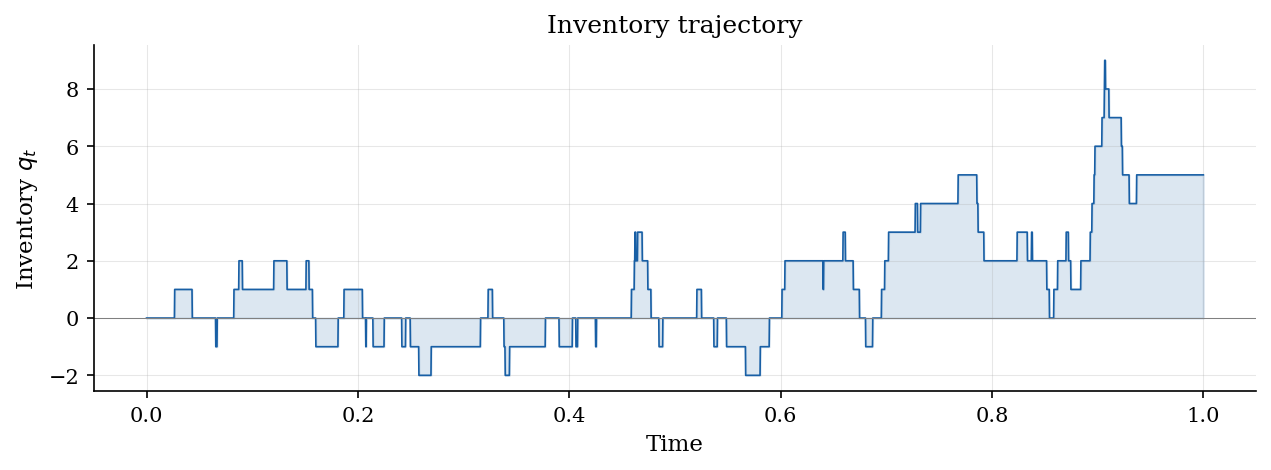

In [16]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(result['time'], result['inventory'], color=COLORS[3], lw=0.8)
ax.axhline(0, color='gray', lw=0.5)
ax.fill_between(result['time'], result['inventory'], 0, alpha=0.15, color=COLORS[3])
ax.set_xlabel('Time')
ax.set_ylabel('Inventory $q_t$')
ax.set_title('Inventory trajectory')
save_fig(fig, '03_market_making', 'as_inventory')
plt.show()


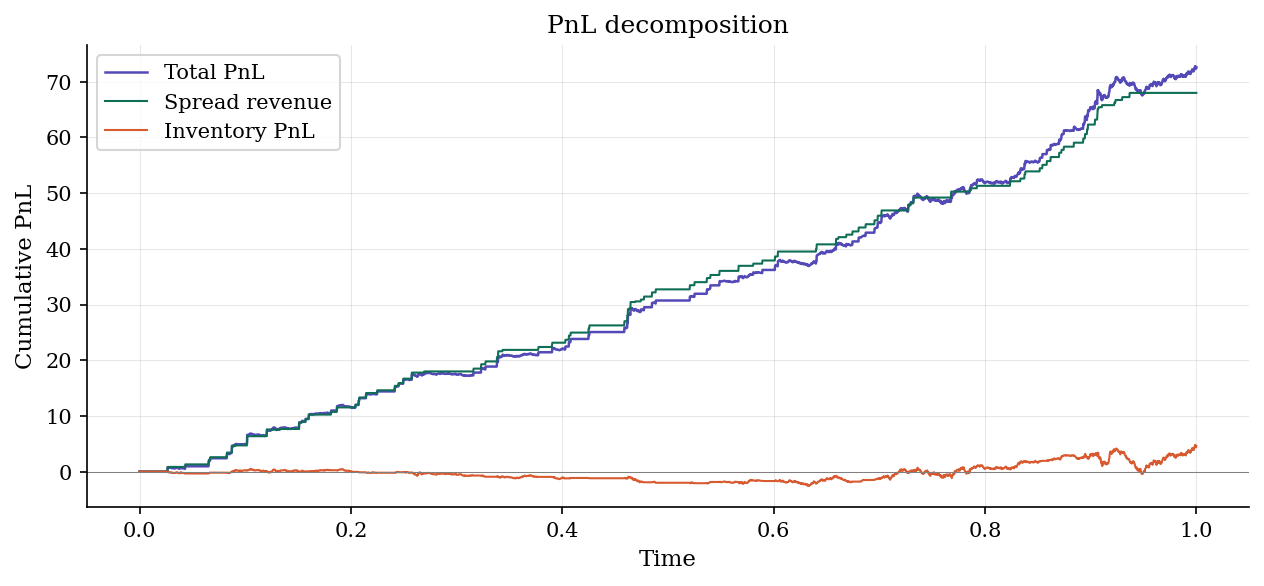

In [17]:
inv_pnl = result['pnl'] - result['spread_revenue']
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(result['time'], result['pnl'], color=COLORS[0], lw=1.2, label='Total PnL')
ax.plot(result['time'], result['spread_revenue'], color=COLORS[1], lw=1.0, label='Spread revenue')
ax.plot(result['time'], inv_pnl, color=COLORS[2], lw=1.0, label='Inventory PnL')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Cumulative PnL')
ax.set_title('PnL decomposition')
ax.legend()
save_fig(fig, '03_market_making', 'as_pnl_decomposition')
plt.show()


In [18]:
gamma_values = np.logspace(-2, 0, 15)
n_sims = 200
final_pnls = np.zeros((len(gamma_values), n_sims))
for i, g in enumerate(gamma_values):
    for j in range(n_sims):
        sim_rng = np.random.default_rng(1000 * i + j)
        res = avellaneda_stoikov_sim(100.0, 2.0, 1.0, 3600, g, 1.5, 140.0, sim_rng)
        final_pnls[i, j] = res['pnl'][-1]
print('Gamma sweep done.')


Gamma sweep done.


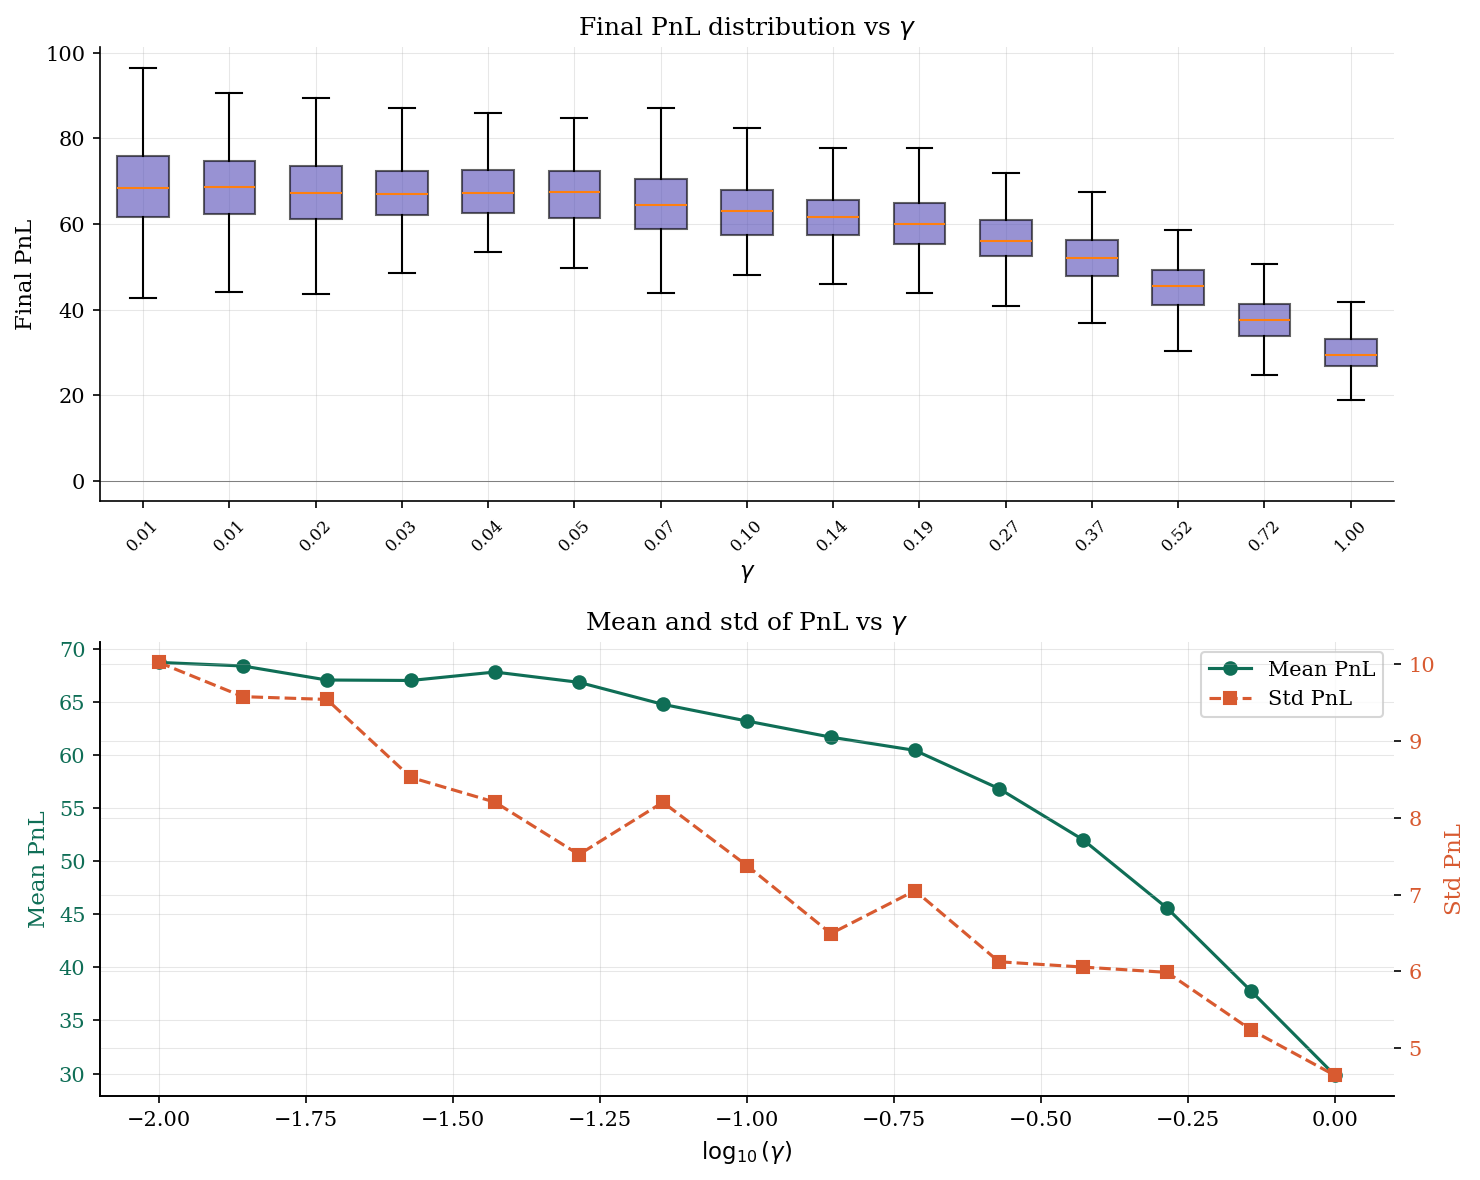

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
bp = ax1.boxplot([final_pnls[i] for i in range(len(gamma_values))],
                 positions=range(len(gamma_values)), widths=0.6,
                 patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor(COLORS[0])
    patch.set_alpha(0.6)
ax1.set_xticks(range(len(gamma_values)))
ax1.set_xticklabels([f'{g:.2f}' for g in gamma_values], rotation=45, fontsize=8)
ax1.set_xlabel(r'$\gamma$')
ax1.set_ylabel('Final PnL')
ax1.set_title(r'Final PnL distribution vs $\gamma$')
ax1.axhline(0, color='gray', lw=0.5)
means = final_pnls.mean(axis=1)
stds = final_pnls.std(axis=1)
ln_g = np.log10(gamma_values)
ax2.plot(ln_g, means, 'o-', color=COLORS[1], label='Mean PnL')
ax2.set_xlabel(r'$\log_{10}(\gamma)$')
ax2.set_ylabel('Mean PnL', color=COLORS[1])
ax2.tick_params(axis='y', labelcolor=COLORS[1])
ax2b = ax2.twinx()
ax2b.plot(ln_g, stds, 's--', color=COLORS[2], label='Std PnL')
ax2b.set_ylabel('Std PnL', color=COLORS[2])
ax2b.tick_params(axis='y', labelcolor=COLORS[2])
ax2.set_title(r'Mean and std of PnL vs $\gamma$')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
fig.tight_layout()
save_fig(fig, '03_market_making', 'as_gamma_sensitivity')
plt.show()


## Section 4 — Adverse-selection premium: low vs high (fixed $\gamma$, $\kappa$)

The factor `adverse_premium_scale` multiplies only the adverse-selection part $(1/\gamma)\ln(1+\gamma/\kappa)$ of the half-spread, and paired runs reuse the same seed so differences isolate that scaling.


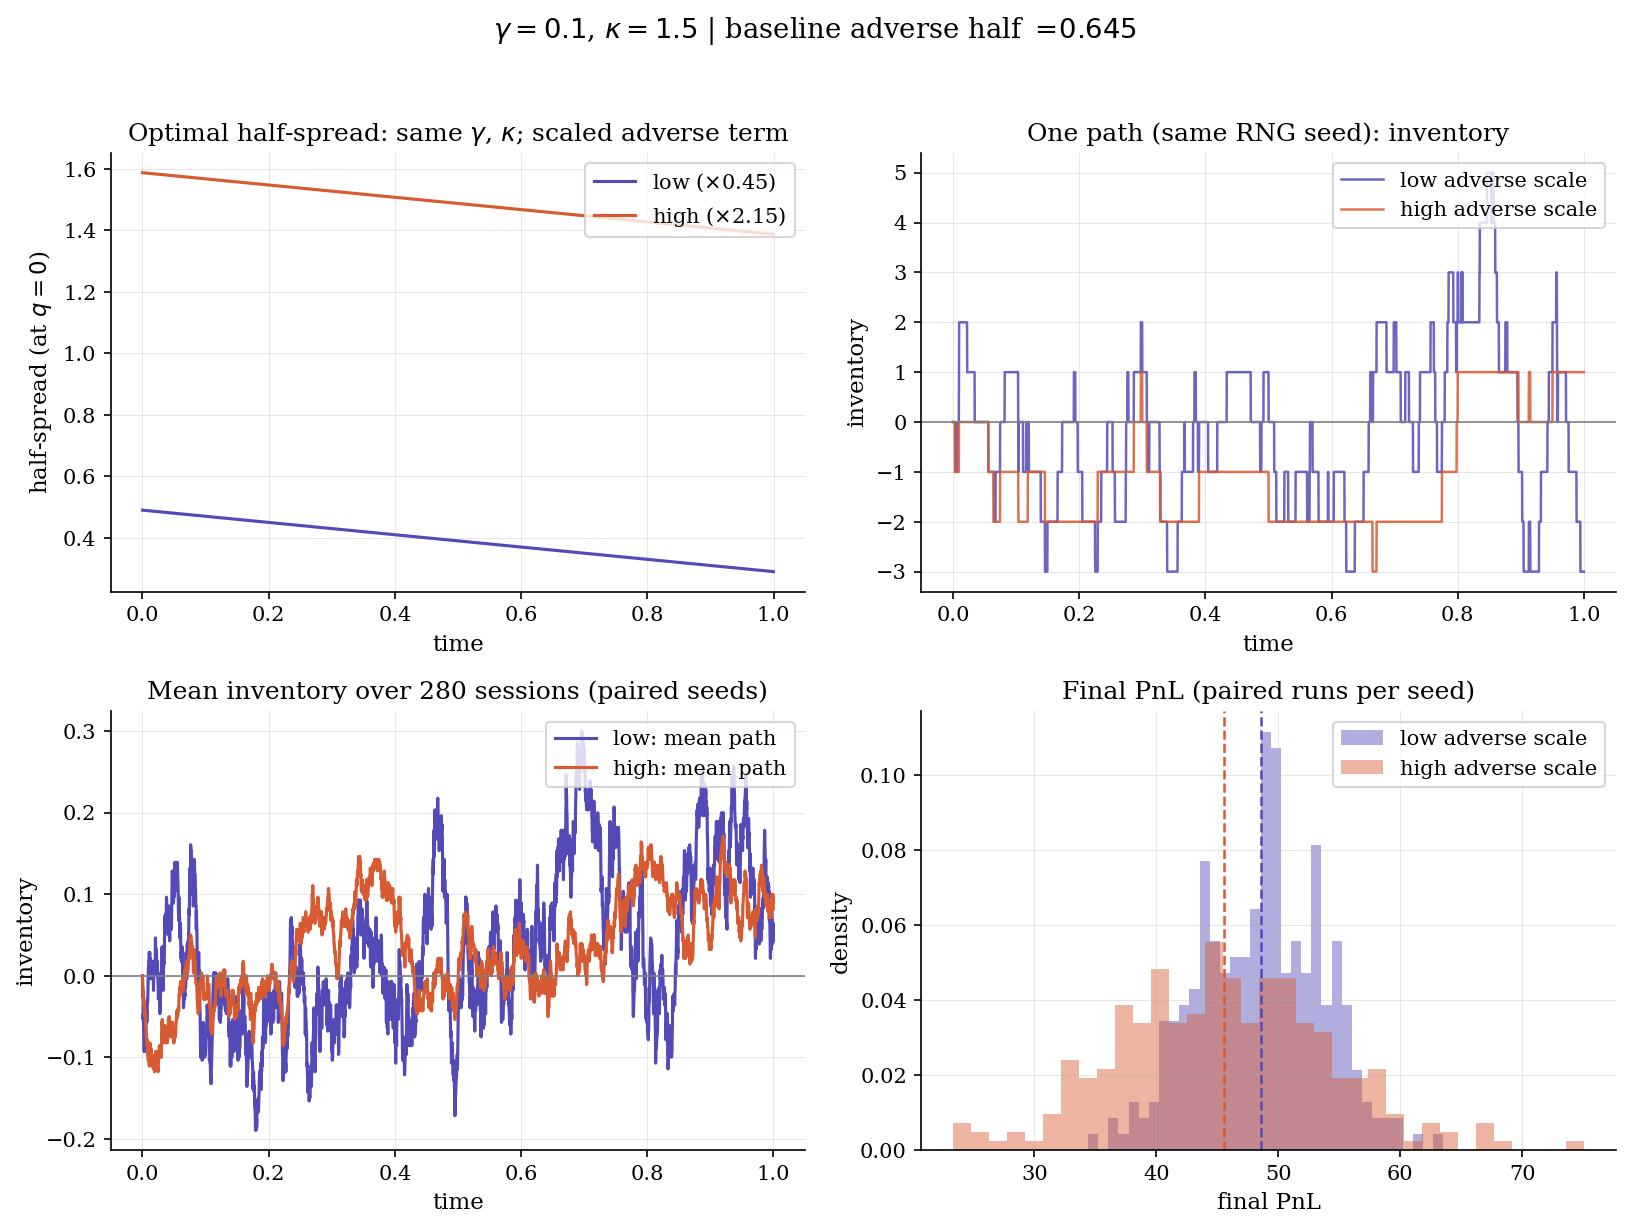

Mean final PnL  low/high:  48.59 / 45.56
Std final PnL   low/high:  5.07 / 8.65


In [20]:
gamma_as, kappa_as = 0.1, 1.5
A_as = 140.0
S0_as, sigma_as, T_as = 100.0, 2.0, 1.0
n_steps_as = 3600

adverse_low, adverse_high = 0.45, 2.15
baseline_adverse_half = (1.0 / gamma_as) * np.log(1.0 + gamma_as / kappa_as)

n_mc_as = 280
pnl_low, pnl_high = [], []
inv_low_runs, inv_high_runs = [], []

for k in range(n_mc_as):
    rng_lo = np.random.default_rng(k)
    r_lo = avellaneda_stoikov_sim(
        S0_as, sigma_as, T_as, n_steps_as,
        gamma_as, kappa_as, A_as, rng_lo,
        adverse_premium_scale=adverse_low,
    )
    rng_hi = np.random.default_rng(k)
    r_hi = avellaneda_stoikov_sim(
        S0_as, sigma_as, T_as, n_steps_as,
        gamma_as, kappa_as, A_as, rng_hi,
        adverse_premium_scale=adverse_high,
    )
    pnl_low.append(r_lo['pnl'][-1])
    pnl_high.append(r_hi['pnl'][-1])
    inv_low_runs.append(r_lo['inventory'])
    inv_high_runs.append(r_hi['inventory'])

pnl_low, pnl_high = np.asarray(pnl_low), np.asarray(pnl_high)
mean_inv_low = np.mean(inv_low_runs, axis=0)
mean_inv_high = np.mean(inv_high_runs, axis=0)

# Single-session overlay (seed 0): quotes widen with higher adverse scale → fewer fills, different inventory
rng0 = np.random.default_rng(0)
ex_lo = avellaneda_stoikov_sim(
    S0_as, sigma_as, T_as, n_steps_as,
    gamma_as, kappa_as, A_as, rng0, adverse_premium_scale=adverse_low,
)
rng0 = np.random.default_rng(0)
ex_hi = avellaneda_stoikov_sim(
    S0_as, sigma_as, T_as, n_steps_as,
    gamma_as, kappa_as, A_as, rng0, adverse_premium_scale=adverse_high,
)
t_ex = ex_lo['time']

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
tau = np.maximum(T_as - t_ex[:-1], 1e-10)
inv_half = 0.5 * gamma_as * sigma_as**2 * tau
ax.plot(t_ex[:-1], inv_half + adverse_low * baseline_adverse_half,
        color=COLORS[0], lw=1.5,
        label=fr'low ($\times${adverse_low})')
ax.plot(t_ex[:-1], inv_half + adverse_high * baseline_adverse_half,
        color=COLORS[2], lw=1.5,
        label=fr'high ($\times${adverse_high})')
ax.set_xlabel('time')
ax.set_ylabel('half-spread (at $q=0$)')
ax.set_title(r'Optimal half-spread: same $\gamma$, $\kappa$; scaled adverse term')
ax.legend(loc='upper right')

ax = axes[0, 1]
ax.plot(t_ex, ex_lo['inventory'], color=COLORS[0], alpha=0.85, lw=1.2, label='low adverse scale')
ax.plot(t_ex, ex_hi['inventory'], color=COLORS[2], alpha=0.85, lw=1.2, label='high adverse scale')
ax.axhline(0, color='0.5', lw=0.8)
ax.set_xlabel('time')
ax.set_ylabel('inventory')
ax.set_title('One path (same RNG seed): inventory')
ax.legend(loc='upper right')

ax = axes[1, 0]
ax.plot(t_ex, mean_inv_low, color=COLORS[0], lw=1.5, label='low: mean path')
ax.plot(t_ex, mean_inv_high, color=COLORS[2], lw=1.5, label='high: mean path')
ax.axhline(0, color='0.5', lw=0.8)
ax.set_xlabel('time')
ax.set_ylabel('inventory')
ax.set_title(fr'Mean inventory over {n_mc_as} sessions (paired seeds)')
ax.legend(loc='upper right')

ax = axes[1, 1]
ax.hist(pnl_low, bins=35, density=True, alpha=0.45, color=COLORS[0], label='low adverse scale')
ax.hist(pnl_high, bins=35, density=True, alpha=0.45, color=COLORS[2], label='high adverse scale')
ax.axvline(pnl_low.mean(), color=COLORS[0], ls='--', lw=1.2)
ax.axvline(pnl_high.mean(), color=COLORS[2], ls='--', lw=1.2)
ax.set_xlabel('final PnL')
ax.set_ylabel('density')
ax.set_title('Final PnL (paired runs per seed)')
ax.legend(loc='upper right')

fig.suptitle(
    fr'$\gamma={gamma_as}$, $\kappa={kappa_as}$ | baseline adverse half $=\!{baseline_adverse_half:.3f}$',
    y=1.02,
)
fig.tight_layout()
save_fig(fig, '03_market_making', 'as_adverse_selection_comparison')
plt.show()

print(f'Mean final PnL  low/high:  {pnl_low.mean():.2f} / {pnl_high.mean():.2f}')
print(f'Std final PnL   low/high:  {pnl_low.std():.2f} / {pnl_high.std():.2f}')


## Prosperity 4 Takeaways

Estimate $\sigma$ from recent mids, fit $A$ and $\kappa$ to realised fill rates versus quote distance, and sweep $\gamma$ to balance inventory risk against spread capture. Let $T-t$ shrink near the horizon so quotes tighten, and add a signal to $r_t$ (e.g. a stat-arb z-score) when you combine market making with directional edge.
